# অধ্যায় ৩: অতত্ত্বাবধানে শিক্ষণ (Unsupervised Learning)
## পাঠ ৩.৩: NMF ও ম্যানিফোল্ড লার্নিং
### (Non-Negative Matrix Factorization & Manifold Learning)

![ML for Kids](https://img.shields.io/badge/ML-for%20Kids-brightgreen)

স্বাগতম! আজ আমরা শিখবো আরও দুটি শক্তিশালী টেকনিক — NMF এবং ম্যানিফোল্ড লার্নিং।

## 🧩 NMF (Non-Negative Matrix Factorization)

### 📖 সহজ ভাষায়:
NMF হলো একটি পদ্ধতি যা ডেটাকে **ছোট ছোট অংশে** (parts) ভাগ করে। NMF শুধুমাত্র সেই ডেটার জন্য কাজ করে যার সব মান **শূন্য বা ধনাত্মক** (non-negative) — যেমন ছবির পিক্সেল, অডিও সিগন্যাল ইত্যাদি।

### 🎨 উদাহরণ:
তোমার কাছে অনেকগুলো মুখের ছবি আছে। NMF এগুলোকে ভাগ করতে পারে:
- কিছু অংশ নাকের জন্য
- কিছু অংশ চোখের জন্য
- কিছু অংশ মুখের জন্য
- কিছু অংশ কানের জন্য

অর্থাৎ NMF ডেটাকে তার **অবিচ্ছেদ্য অংশে** (parts-based decomposition) ভাগ করে ফেলে। এটা অনেকটা লেগো ব্লকের মতো — প্রতিটি ছবি কিছু মৌলিক ব্লক দিয়ে তৈরি!

### ⚙️ NMF কিভাবে কাজ করে?
NMF একটি ম্যাট্রিক্স X-কে দুটি ছোট ম্যাট্রিক্সের গুণফল হিসেবে প্রকাশ করে:
**X ≈ W × H**
- W = আমাদের ডেটার বৈশিষ্ট্য (features)
- H = প্রতিটি অংশের গুরুত্ব (weights)

এবং শর্ত: W এবং H-এর সব মানই >= ০ (শূন্য বা ধনাত্মক) — তাই নাম Non-Negative।

### 📊 PCA-র সাথে পার্থক্য:
- PCA ডেটার **বৈচিত্র্য** (variance) ধরে রাখার চেষ্টা করে
- NMF ডেটার **অংশগুলোর** (parts) সন্ধান করে
- PCA-তে মান নেগেটিভও হতে পারে, NMF-এ শুধু ধনাত্মক
- NMF-এর ফলাফল বোঝা সহজ (interpretable) কারণ মানগুলো ধনাত্মক

In [1]:
# প্রয়োজনীয় লাইব্রেরি
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA, NMF
from sklearn.manifold import TSNE
from sklearn.datasets import load_digits, make_swiss_roll, load_iris
from sklearn.preprocessing import StandardScaler, MinMaxScaler

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print("✅ সব লাইব্রেরি লোড হয়েছে!")

✅ সব লাইব্রেরি লোড হয়েছে!


## 🖼️ Digits ডেটাতে NMF

চলো, হাতের লেখা সংখ্যার ডেটাতে (Digits) NMF প্রয়োগ করি। Digits ডেটার সব মানই ০-১৬-এর মধ্যে (পিক্সেল ভ্যালু), তাই NMF-এর জন্য উপযুক্ত। আমরা NMF ব্যবহার করে ডেটা থেকে মৌলিক অংশ (components) বের করব এবং দেখব সেগুলো কেমন দেখতে।

In [2]:
# Digits ডেটাসেট লোড
digits = load_digits()
X_digits = digits.data
y_digits = digits.target
images = digits.images
print("📊 Digits ডেটাসেট:")
print(f"   ডেটা পয়েন্ট: {X_digits.shape[0]}")
print(f"   ফিচার (পিক্সেল): {X_digits.shape[1]}")
print(f"   ক্লাস: 0-9")
print(f"   মানের রেঞ্জ: {X_digits.min()} - {X_digits.max()}")

📊 Digits ডেটাসেট:
   ডেটা পয়েন্ট: 1797
   ফিচার (পিক্সেল): 64
   ক্লাস: 0-9
   মানের রেঞ্জ: 0.0 - 16.0


In [3]:
# NMF প্রয়োগ করি
n_components = 16  # 16টি মৌলিক অংশ

nmf = NMF(n_components=n_components, random_state=42, max_iter=500)
W = nmf.fit_transform(X_digits)  # W: ডেটার প্রতিনিধিত্ব
H = nmf.components_  # H: মৌলিক অংশগুলো

print(f"📐 W-এর আকৃতি: {W.shape} (ডেটা পয়েন্ট × কম্পোনেন্ট)")
print(f"📐 H-এর আকৃতি: {H.shape} (কম্পোনেন্ট × ফিচার)")
print()
print(f"🧩 মোট মৌলিক অংশ (components) পেয়েছি: {n_components}টি")
print()
print("✅ NMF সম্পন্ন হয়েছে!")

📐 W-এর আকৃতি: (1797, 16) (ডেটা পয়েন্ট × কম্পোনেন্ট)
📐 H-এর আকৃতি: (16, 64) (কম্পোনেন্ট × ফিচার)

🧩 মোট মৌলিক অংশ (components) পেয়েছি: 16টি

✅ NMF সম্পন্ন হয়েছে!


### NMF-এর মৌলিক অংশগুলো দেখা

NMF যে মৌলিক অংশগুলো (components) বের করেছে, সেগুলো ৮×৮ ইমেজে রূপান্তর করে দেখি। প্রতিটি অংশ সংখ্যার কোনো না কোনো বৈশিষ্ট্য ধারণ করে — যেমন গোলাকার অংশ, সরল রেখা, বক্ররেখা ইত্যাদি।

C:\Users\hp\AppData\Local\Temp\ipykernel_4852\3789389224.py:11: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4852\3789389224.py:11: UserWarning: Glyph 2447 (\N{BENGALI LETTER E}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4852\3789389224.py:11: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4852\3789389224.py:11: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4852\3789389224.py:11: UserWarning: Glyph 2478 (\N{BENGALI LETTER MA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4852\3789389224.py:11: UserWarning: Glyph 2508 (\N{BENGALI VOWEL SIGN AU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykerne

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2447 (\N{BENGALI LETTER E}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2478 (\N

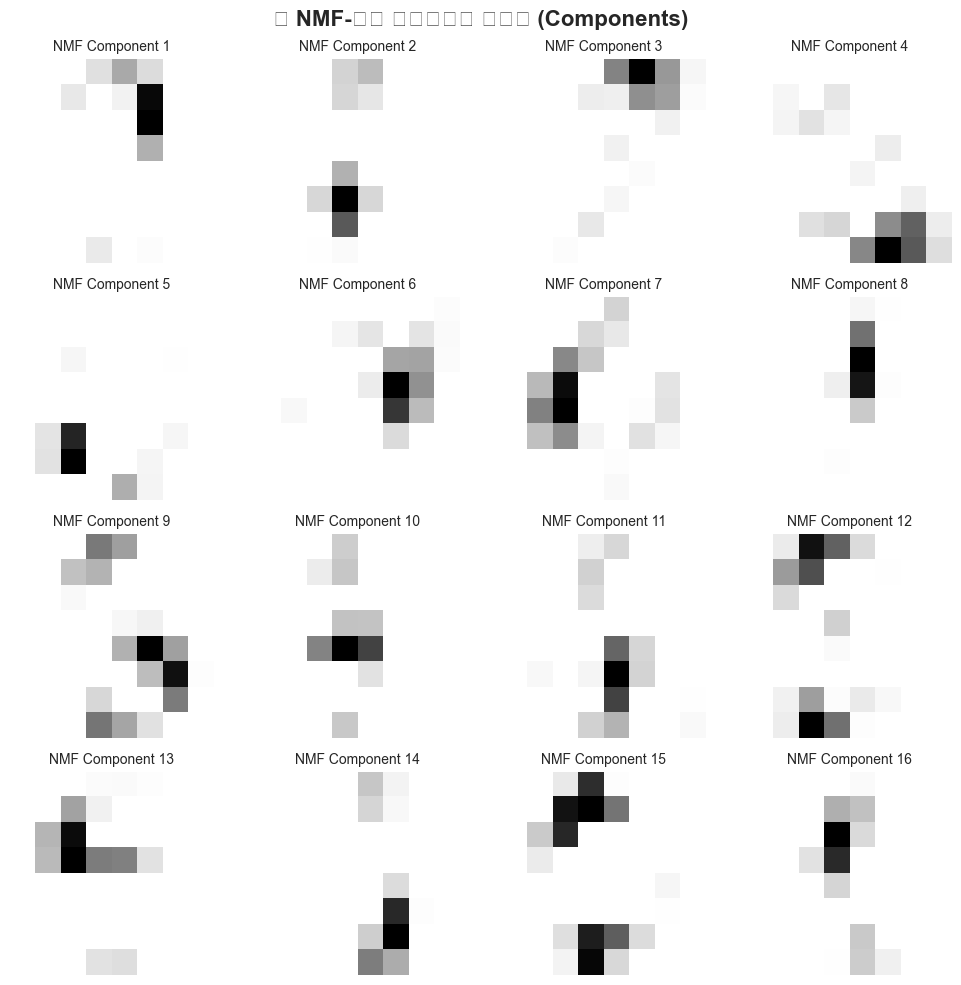

👆 প্রতিটি ছবি NMF-এর একটি মৌলিক অংশ। লক্ষ্য করো এরা বিভিন্ন আকার ও প্যাটার্ন!


In [4]:
# NMF-এর কম্পোনেন্টগুলো ভিজুয়ালাইজ করি
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.ravel()):
    if i < n_components:
        component_img = H[i].reshape(8, 8)
        ax.imshow(component_img, cmap='gray_r')
        ax.set_title(f'NMF Component {i+1}', fontsize=10)
    ax.axis('off')

plt.suptitle('🎨 NMF-এর মৌলিক অংশ (Components)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
print("👆 প্রতিটি ছবি NMF-এর একটি মৌলিক অংশ। লক্ষ্য করো এরা বিভিন্ন আকার ও প্যাটার্ন!")

### PCA-র সাথে NMF-এর তুলনা

চলো, একই ডেটাতে PCA প্রয়োগ করি এবং দেখি PCA-র কম্পোনেন্টগুলোর সাথে NMF-এর পার্থক্য কী।

C:\Users\hp\AppData\Local\Temp\ipykernel_4852\3639937354.py:13: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4852\3639937354.py:13: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4852\3639937354.py:13: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4852\3639937354.py:13: UserWarning: Glyph 2453 (\N{BENGALI LETTER KA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4852\3639937354.py:13: UserWarning: Glyph 2478 (\N{BENGALI LETTER MA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4852\3639937354.py:13: UserWarning: Glyph 2509 (\N{BENGALI SIGN VIRAMA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2453 (\N{BENGALI LETTER KA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2478 (\

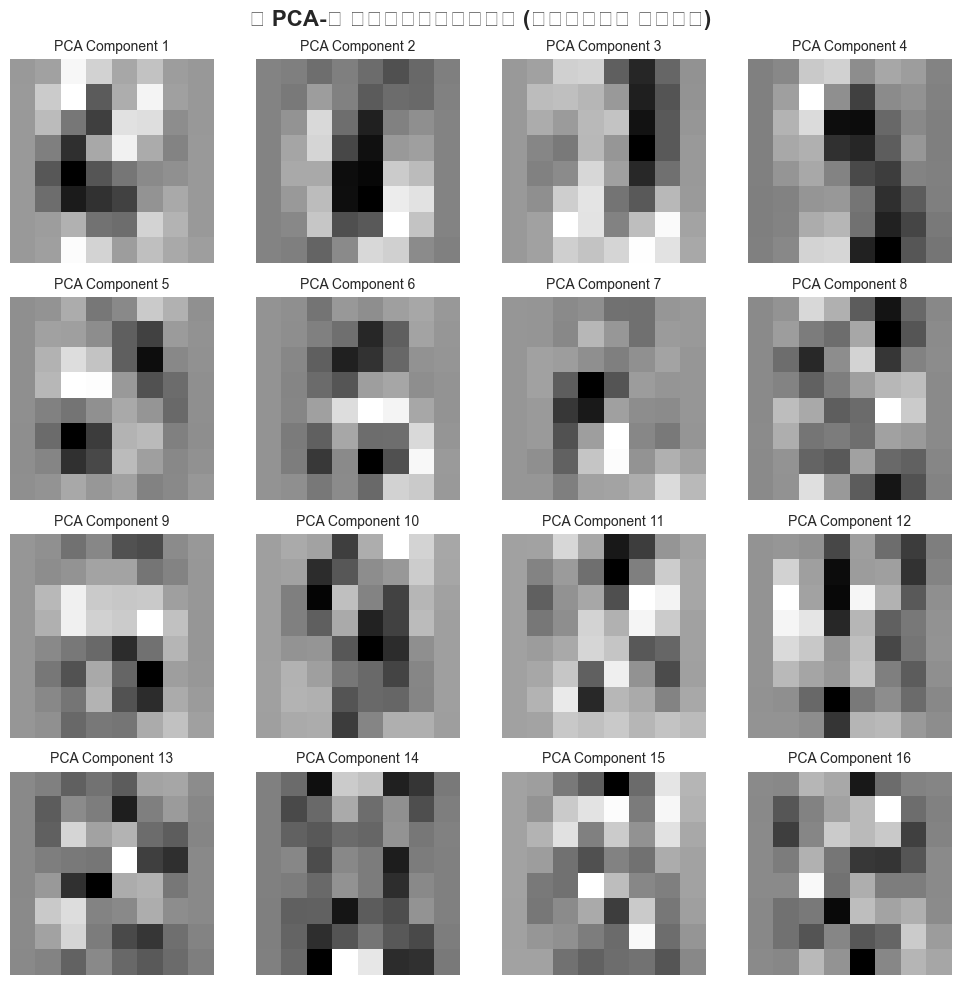

👆 PCA-র কম্পোনেন্টগুলোতে ধনাত্মক ও ঋণাত্মক উভয় মানই আছে (কালো ও সাদা অংশ)
NMF-এর কম্পোনেন্টগুলোতে শুধু ধনাত্মক মান আছে — ফলে সেগুলো বোঝা সহজ!


In [5]:
# PCA-র কম্পোনেন্টগুলোও দেখা যাক তুলনার জন্য
pca = PCA(n_components=16)
pca.fit(X_digits)

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.ravel()):
    component_img = pca.components_[i].reshape(8, 8)
    ax.imshow(component_img, cmap='gray_r')
    ax.set_title(f'PCA Component {i+1}', fontsize=10)
    ax.axis('off')

plt.suptitle('🎨 PCA-র কম্পোনেন্ট (তুলনার জন্য)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
print("👆 PCA-র কম্পোনেন্টগুলোতে ধনাত্মক ও ঋণাত্মক উভয় মানই আছে (কালো ও সাদা অংশ)")
print("NMF-এর কম্পোনেন্টগুলোতে শুধু ধনাত্মক মান আছে — ফলে সেগুলো বোঝা সহজ!")

### NMF দিয়ে পুনর্গঠন

NMF মূল ডেটাকে W × H দিয়ে приблизительно পুনর্গঠন করতে পারে। চলো কিছু আসল ডিজিট এবং তাদের NMF-এর মাধ্যমে পুনর্গঠিত সংস্করণ তুলনা করি।

C:\Users\hp\AppData\Local\Temp\ipykernel_4852\631570682.py:15: UserWarning: Glyph 2438 (\N{BENGALI LETTER AA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4852\631570682.py:15: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4852\631570682.py:15: UserWarning: Glyph 2488 (\N{BENGALI LETTER SA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4852\631570682.py:15: UserWarning: Glyph 2482 (\N{BENGALI LETTER LA}) missing from font(s) Arial.
  plt.tight_layout()


C:\Users\hp\AppData\Local\Temp\ipykernel_4852\631570682.py:15: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4852\631570682.py:15: UserWarning: Glyph 2465 (\N{BENGALI LETTER DDA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4852\631570682.py:15: UserWarning: Glyph 2495 (\N{BENGALI VOWEL SIGN I}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4852\631570682.py:15: UserWarning: Glyph 2460 (\N{BENGALI LETTER JA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4852\631570682.py:15: UserWarning: Glyph 2463 (\N{BENGALI LETTER TTA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4852\631570682.py:15: UserWarning: Glyph 2441 (\N{BENGALI LETTER U}) missing from font(s) Arial.
  plt.tight_layout

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2438 (\N{BENGALI LETTER AA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2488 (\N{BENGALI LETTER SA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2465 (\N{BENGALI LETTER DDA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2495 (\N{BENGALI VOWEL SIGN I}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2441 (\N{BENGALI LETTER U}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\

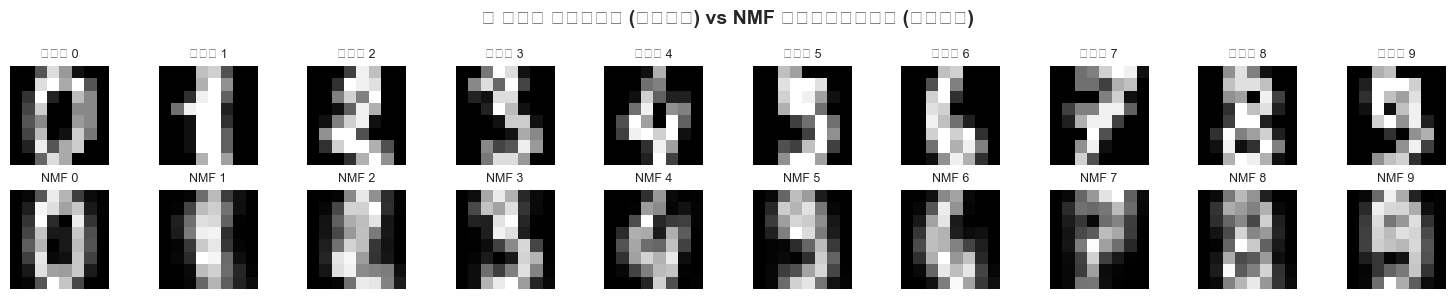

👆 NMF মাত্র 16টি অংশ ব্যবহার করে প্রায় আসল ছবির মতোই পুনর্গঠন করতে পেরেছে!


In [6]:
# আসল ডিজিট vs NMF পুনর্গঠন
X_reconstructed = nmf.inverse_transform(W)

fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(10):
    axes[0, i].imshow(digits.images[i], cmap='gray')
    axes[0, i].set_title(f'আসল {y_digits[i]}', fontsize=9)
    axes[0, i].axis('off')
    
    axes[1, i].imshow(X_reconstructed[i].reshape(8, 8), cmap='gray')
    axes[1, i].set_title(f'NMF {y_digits[i]}', fontsize=9)
    axes[1, i].axis('off')

plt.suptitle('🔄 আসল ডিজিট (উপরে) vs NMF পুনর্গঠন (নিচে)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("👆 NMF মাত্র 16টি অংশ ব্যবহার করে প্রায় আসল ছবির মতোই পুনর্গঠন করতে পেরেছে!")

## 🌊 ম্যানিফোল্ড লার্নিং

### গল্প: সুইস রোল (Swiss Roll)

তোমার হাতে একটা কাগজ আছে। তুমি সেটাকে পেঁচিয়ে একটা রোল বানালে — যেমন সুইস রোল কেক। এই ৩D রোলের উপর অনেকগুলো পয়েন্ট আছে।

এখন, এই পয়েন্টগুলোর মধ্যে দূরত্ব মাপা ৩D-তে কঠিন। কিন্তু তুমি যদি রোলটাকে খুলে ফেলো (আনরোল করো), তাহলে পয়েন্টগুলোর আসল সম্পর্ক বোঝা সহজ হবে।

**ম্যানিফোল্ড লার্নিং** ঠিক এই কাজটাই করে — এটি উচ্চমাত্রার ডেটার আসল কাঠামো (underlying structure) খুঁজে বের করে এবং সেটাকে নিচুমাত্রায় "আনরোল" করে।

### 🧠 মূল ধারণা:
- **ম্যানিফোল্ড** (Manifold) = একটি বাঁকা পৃষ্ঠ যা উচ্চমাত্রায় অবস্থিত কিন্তু নিচুমাত্রার কাঠামো আছে
- উদাহরণ: পৃথিবী ৩D-তে গোলাকার, কিন্তু ২D ম্যাপ (যেমন বিশ্বের মানচিত্র) ব্যবহার করি — এটাই ম্যানিফোল্ড লার্নিং
- ম্যানিফোল্ড লার্নিং ধরে নেয় যে ডেটা আসলে একটি নিচুমাত্রার ম্যানিফোল্ডে থাকে

চলো, আমরা সুইস রোল ডেটা তৈরি করি এবং বিভিন্ন পদ্ধতিতে ভিজুয়ালাইজ করি।

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127874 (\N{BIRTHDAY CAKE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2439 (\N{BENGALI LETTER I}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


📊 Swiss Roll ডেটাসেট:
   ডেটা পয়েন্ট: 1000
   ফিচার: 3 (3D ডেটা)


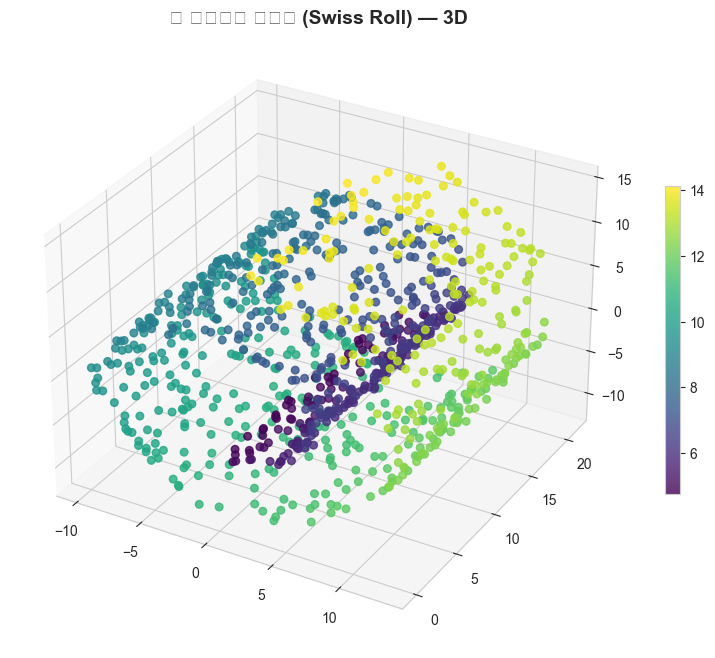

👆 দেখো, ডেটা একটা পেঁচানো রোলের মতো!


In [7]:
# Swiss Roll ডেটা তৈরি
X_swiss, color_swiss = make_swiss_roll(n_samples=1000, noise=0.2, random_state=42)
print("📊 Swiss Roll ডেটাসেট:")
print(f"   ডেটা পয়েন্ট: {X_swiss.shape[0]}")
print(f"   ফিচার: {X_swiss.shape[1]} (3D ডেটা)")

# 3D ভিজুয়ালাইজেশন
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_swiss[:, 0], X_swiss[:, 1], X_swiss[:, 2],
                     c=color_swiss, cmap='viridis', s=30, alpha=0.8)
ax.set_title('🎂 সুইস রোল (Swiss Roll) — 3D', fontsize=14, fontweight='bold')
plt.colorbar(scatter, shrink=0.5)
plt.show()
print("👆 দেখো, ডেটা একটা পেঁচানো রোলের মতো!")

### PCA vs ম্যানিফোল্ড লার্নিং

PCA যদি এই ডেটার মাত্রা কমায়, তাহলে কি রোলটাকে সঠিকভাবে "আনরোল" করতে পারবে?

PCA একটি **লিনিয়ার** (সরলরৈখিক) পদ্ধতি — এটি ধরে নেয় ডেটা সরলরেখা বরাবর বিস্তৃত। কিন্তু সুইস রোল বাঁকা! তাই PCA এখানে ভালো কাজ করবে না।

ম্যানিফোল্ড লার্নিং পদ্ধতি (যেমন t-SNE) **নন-লিনিয়ার** (অসরলরৈখিক) — এটি বাঁকা পৃষ্ঠকেও সঠিকভাবে আনরোল করতে পারে।

চলো, পার্থক্য দেখি!

C:\Users\hp\AppData\Local\Temp\ipykernel_4852\668154052.py:27: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4852\668154052.py:27: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4852\668154052.py:27: UserWarning: Glyph 2474 (\N{BENGALI LETTER PA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4852\668154052.py:27: UserWarning: Glyph 2488 (\N{BENGALI LETTER SA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4852\668154052.py:27: UserWarning: Glyph 2497 (\N{BENGALI VOWEL SIGN U}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4852\668154052.py:27: UserWarning: Glyph 2439 (\N{BENGALI LETTER I}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4852

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2474 (\N{BENGALI LETTER PA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2488 (\N{BENGALI LETTER SA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2497 (

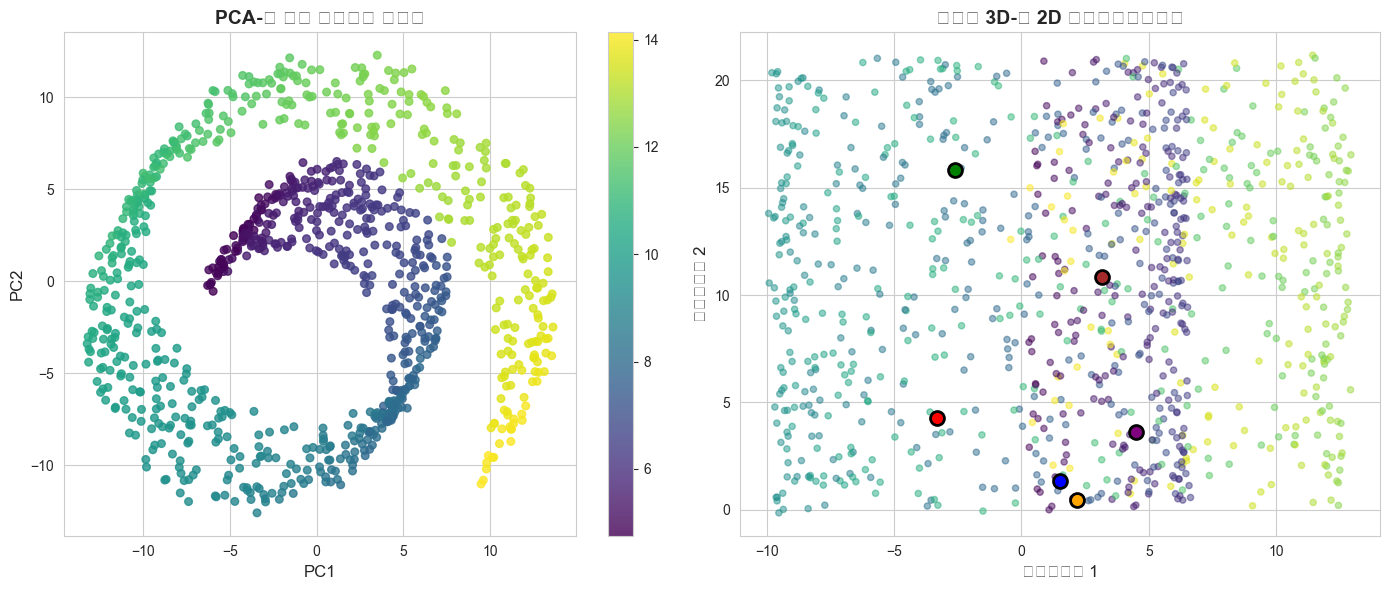

👆 PCA রোলটিকে সঠিকভাবে আনরোল করতে পারেনি — কারণ PCA লিনিয়ার!


In [8]:
# PCA দিয়ে সুইস রোলের মাত্রা কমানো
pca_swiss = PCA(n_components=2)
X_swiss_pca = pca_swiss.fit_transform(X_swiss)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PCA ফলাফল
scatter1 = axes[0].scatter(X_swiss_pca[:, 0], X_swiss_pca[:, 1],
                           c=color_swiss, cmap='viridis', s=30, alpha=0.8)
axes[0].set_title('PCA-র পর সুইস রোল', fontsize=14, fontweight='bold')
axes[0].set_xlabel('PC1', fontsize=12)
axes[0].set_ylabel('PC2', fontsize=12)
plt.colorbar(scatter1, ax=axes[0])

# আসল রোলের উপর কিছু পয়েন্ট হাইলাইট
point_idx = np.array([0, 100, 200, 300, 400, 500])
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']
scatter2 = axes[1].scatter(X_swiss[:, 0], X_swiss[:, 1],
                           c=color_swiss, cmap='viridis', s=20, alpha=0.5)
for i, idx in enumerate(point_idx):
    axes[1].scatter(X_swiss[idx, 0], X_swiss[idx, 1], c=colors[i], s=100, 
                   edgecolors='k', linewidths=2, zorder=5)
axes[1].set_title('আসল 3D-র 2D প্রজেকশন', fontsize=14, fontweight='bold')
axes[1].set_xlabel('ফিচার 1', fontsize=12)
axes[1].set_ylabel('ফিচার 2', fontsize=12)

plt.tight_layout()
plt.show()
print("👆 PCA রোলটিকে সঠিকভাবে আনরোল করতে পারেনি — কারণ PCA লিনিয়ার!")

## 🎯 t-SNE (t-distributed Stochastic Neighbor Embedding)

t-SNE একটি অত্যন্ত শক্তিশালী ম্যানিফোল্ড লার্নিং পদ্ধতি যা বিশেষ করে **ভিজুয়ালাইজেশন**-এর জন্য ব্যবহার করা হয়।

### t-SNE কিভাবে কাজ করে? (সহজ ভাষায়)

1. **উচ্চমাত্রায়**: t-SNE প্রতিটি পয়েন্টের কাছের প্রতিবেশীদের চিহ্নিত করে
2. **নিচুমাত্রায়**: এটি পয়েন্টগুলোকে এমনভাবে সাজায় যেন কাছের পয়েন্টগুলো কাছেই থাকে এবং দূরের পয়েন্টগুলো দূরে থাকে
3. **গোলমেলে দূরত্ব**: উচ্চমাত্রার জটিল দূরত্বকে নিচুমাত্রায় সংরক্ষণের চেষ্টা করে

### ⚠️ t-SNE-র কিছু বিষয়:
- এটি **স্টোকাস্টিক** (random) — প্রতি বার চালালে একটু ভিন্ন ফল আসতে পারে
- এটি **নন-লিনিয়ার** — বাঁকা ডেটার জন্য ভালো
- **perplexity** প্যারামিটারটি গুরুত্বপূর্ণ (ডিফল্ট ৩০)
- t-SNE **শুধু ভিজুয়ালাইজেশন**-এর জন্য — নতুন ডেটা ট্রান্সফর্ম করতে পারে না
- PCA-র চেয়ে **ধীর** (বড় ডেটার জন্য সময় বেশি লাগে)

চলো, Digits ডেটাতে t-SNE প্রয়োগ করি এবং PCA-র সাথে তুলনা করি!

In [9]:
# Digits ডেটাতে t-SNE প্রয়োগ
print("⏳ t-SNE চালানো হচ্ছে... (একটু সময় লাগতে পারে)")

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_digits_tsne = tsne.fit_transform(X_digits)
print("✅ t-SNE সম্পন্ন হয়েছে!")
print(f"📊 t-SNE-র পর ডেটার আকৃতি: {X_digits_tsne.shape}")

⏳ t-SNE চালানো হচ্ছে... (একটু সময় লাগতে পারে)


✅ t-SNE সম্পন্ন হয়েছে!
📊 t-SNE-র পর ডেটার আকৃতি: (1797, 2)


C:\Users\hp\AppData\Local\Temp\ipykernel_4852\2067133367.py:23: UserWarning: Glyph 2465 (\N{BENGALI LETTER DDA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4852\2067133367.py:23: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4852\2067133367.py:23: UserWarning: Glyph 2503 (\N{BENGALI VOWEL SIGN E}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4852\2067133367.py:23: UserWarning: Glyph 2463 (\N{BENGALI LETTER TTA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4852\2067133367.py:23: UserWarning: Glyph 2494 (\N{BENGALI VOWEL SIGN AA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_4852\2067133367.py:23: UserWarning: Glyph 2495 (\N{BENGALI VOWEL SIGN I}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Tem

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2465 (\N{BENGALI LETTER DDA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2503 (\N{BENGALI VOWEL SIGN E}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2463 (\N{BENGALI LETTER TTA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2460 (\N{BENGALI LETTER JA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


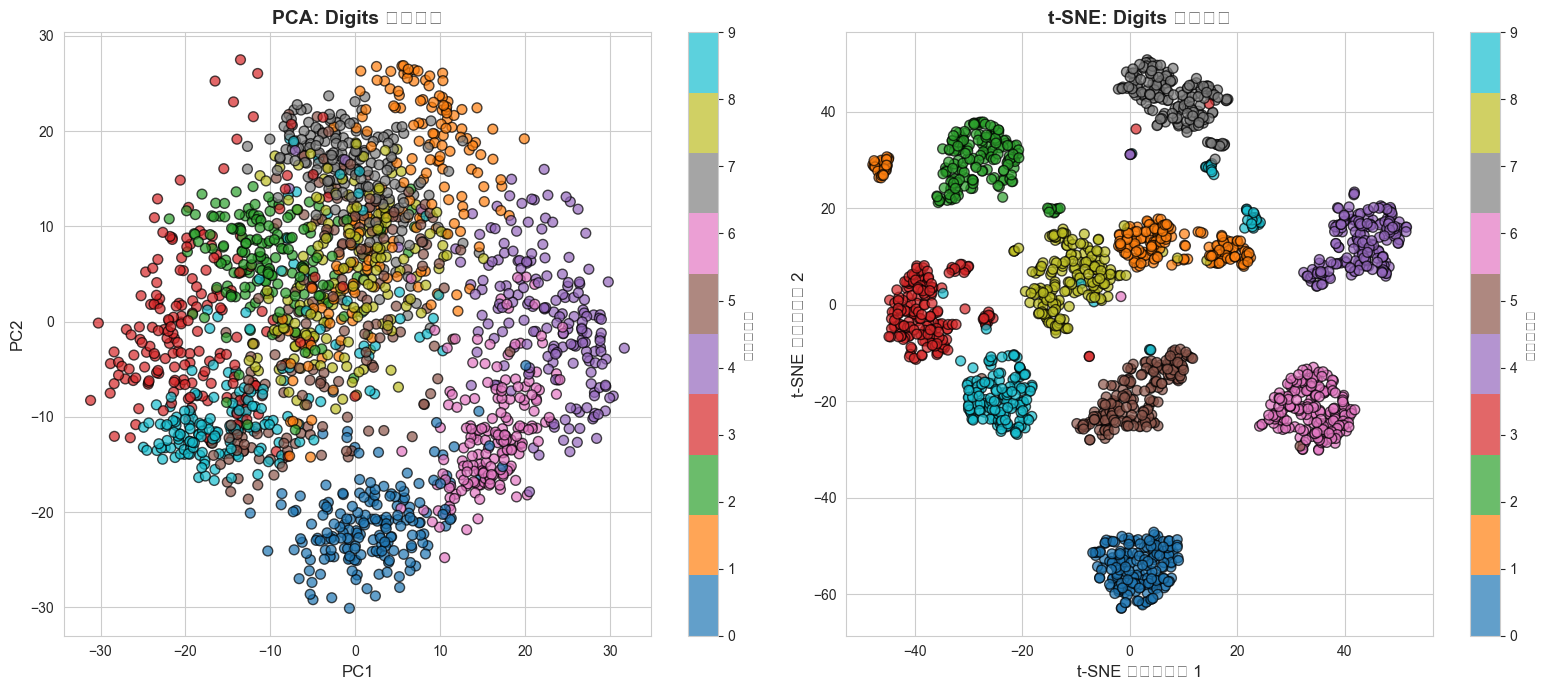

👆 t-SNE ক্লাসগুলোর মধ্যে অনেক পরিষ্কার separation দেখিয়েছে!
PCA মোটামুটি আলাদা করতে পেরেছে, কিন্তু t-SNE-র তুলনায় কম পরিষ্কার।


In [10]:
# PCA vs t-SNE: Digits ডেটার ভিজুয়ালাইজেশন তুলনা
pca_digits = PCA(n_components=2)
X_digits_pca = pca_digits.fit_transform(X_digits)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# PCA প্লট
scatter1 = axes[0].scatter(X_digits_pca[:, 0], X_digits_pca[:, 1],
                           c=y_digits, cmap='tab10', edgecolors='k', s=50, alpha=0.7)
axes[0].set_title('PCA: Digits ডেটা', fontsize=14, fontweight='bold')
axes[0].set_xlabel('PC1', fontsize=12)
axes[0].set_ylabel('PC2', fontsize=12)
plt.colorbar(scatter1, ax=axes[0], label='ডিজিট')

# t-SNE প্লট
scatter2 = axes[1].scatter(X_digits_tsne[:, 0], X_digits_tsne[:, 1],
                           c=y_digits, cmap='tab10', edgecolors='k', s=50, alpha=0.7)
axes[1].set_title('t-SNE: Digits ডেটা', fontsize=14, fontweight='bold')
axes[1].set_xlabel('t-SNE ফিচার 1', fontsize=12)
axes[1].set_ylabel('t-SNE ফিচার 2', fontsize=12)
plt.colorbar(scatter2, ax=axes[1], label='ডিজিট')

plt.tight_layout()
plt.show()
print("👆 t-SNE ক্লাসগুলোর মধ্যে অনেক পরিষ্কার separation দেখিয়েছে!")
print("PCA মোটামুটি আলাদা করতে পেরেছে, কিন্তু t-SNE-র তুলনায় কম পরিষ্কার।")

### t-SNE-এর Perplexity প্যারামিটার নিয়ে খেলা

Perplexity হলো t-SNE-র একটি গুরুত্বপূর্ণ প্যারামিটার। এটি নির্ধারণ করে প্রতিটি পয়েন্ট কতগুলো প্রতিবেশী বিবেচনা করবে। সাধারণত ৫-৫০-এর মধ্যে মান ব্যবহার করা হয়।

ভাবো, তুমি যদি একটা দলে বন্ধুদের বসাও — perplexity কম হলে শুধু খুব কাছের বন্ধুদের সাথে মিলিয়ে বসো, perplexity বেশি হলে অনেক দূরের বন্ধুকেও বিবেচনা করো।

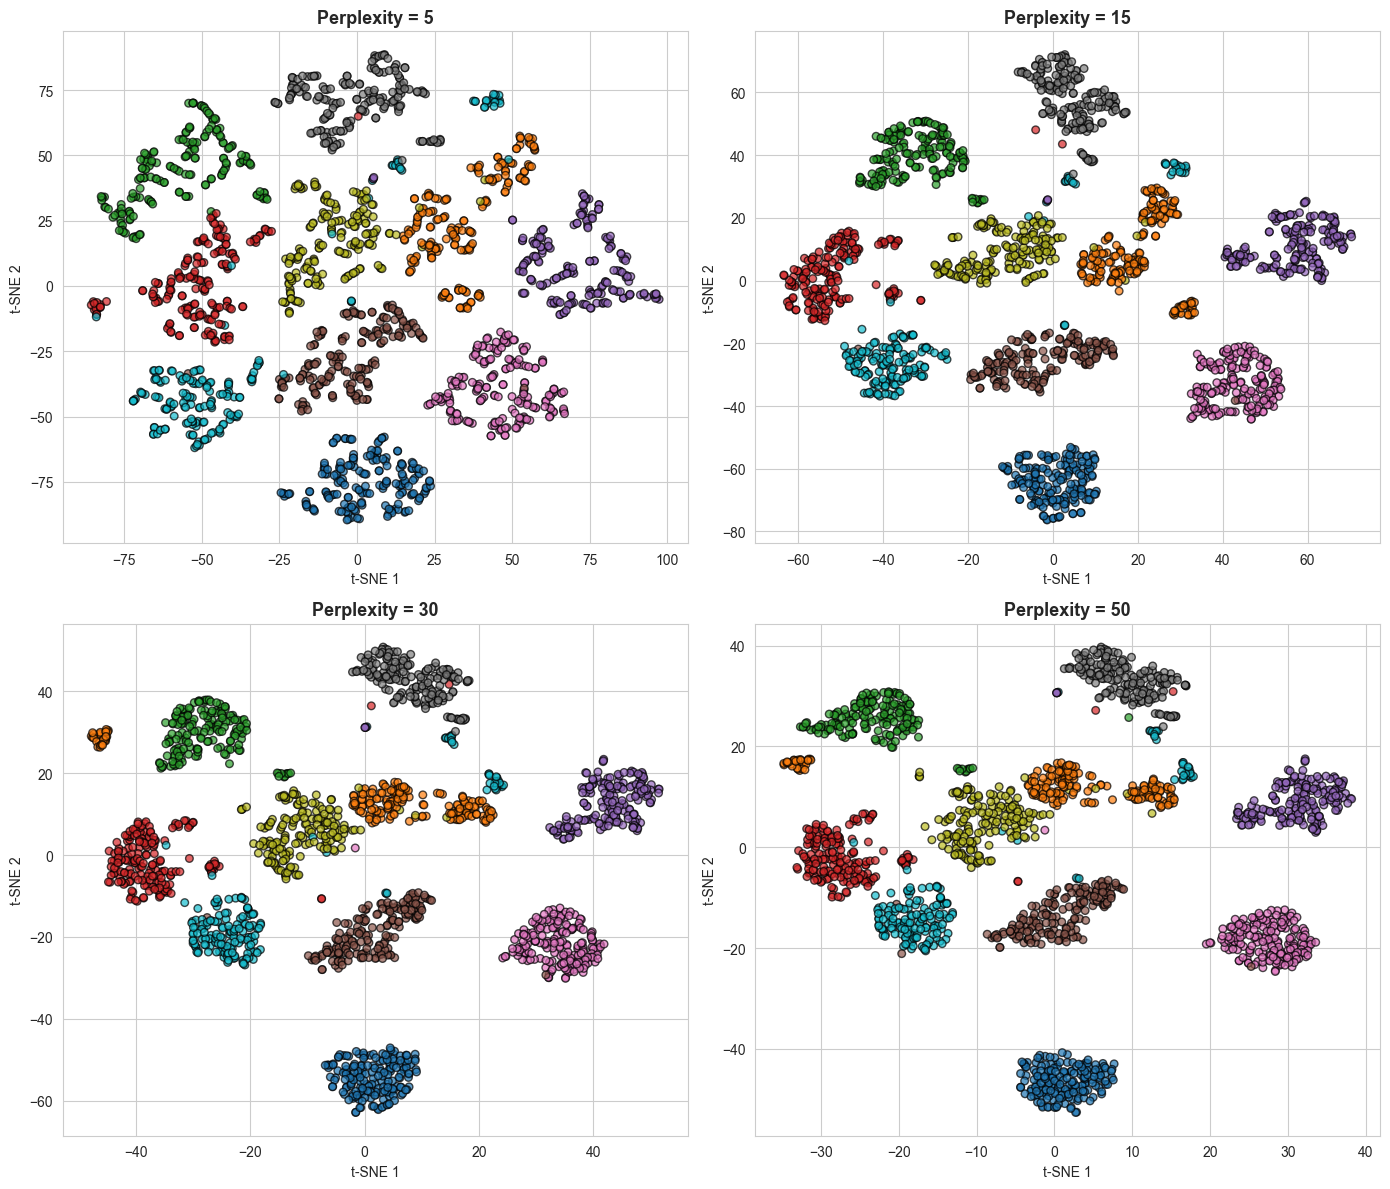

👆 Perplexity পরিবর্তনের সাথে সাথে গ্রুপগুলো কেমন বদলাচ্ছে দেখো!
ছোট perplexity (5): বেশি সংখ্যক ছোট ছোট গ্রুপ
বড় perplexity (50): বড় বড় গ্রুপ, কম বিস্তারিত


In [11]:
# বিভিন্ন perplexity মানের সাথে t-SNE
perplexities = [5, 15, 30, 50]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for i, (perp, ax) in enumerate(zip(perplexities, axes.ravel())):
    tsne_p = TSNE(n_components=2, random_state=42, perplexity=perp, max_iter=1000)
    X_tsne_p = tsne_p.fit_transform(X_digits)
    
    scatter = ax.scatter(X_tsne_p[:, 0], X_tsne_p[:, 1],
                         c=y_digits, cmap='tab10', edgecolors='k', s=30, alpha=0.7)
    ax.set_title(f'Perplexity = {perp}', fontsize=13, fontweight='bold')
    ax.set_xlabel('t-SNE 1', fontsize=10)
    ax.set_ylabel('t-SNE 2', fontsize=10)

plt.tight_layout()
plt.show()
print("👆 Perplexity পরিবর্তনের সাথে সাথে গ্রুপগুলো কেমন বদলাচ্ছে দেখো!")
print("ছোট perplexity (5): বেশি সংখ্যক ছোট ছোট গ্রুপ")
print("বড় perplexity (50): বড় বড় গ্রুপ, কম বিস্তারিত")

### Iris ডেটাতে PCA vs t-SNE

চলো, Iris ডেটাতেও t-SNE প্রয়োগ করে PCA-র সাথে তুলনা করি।

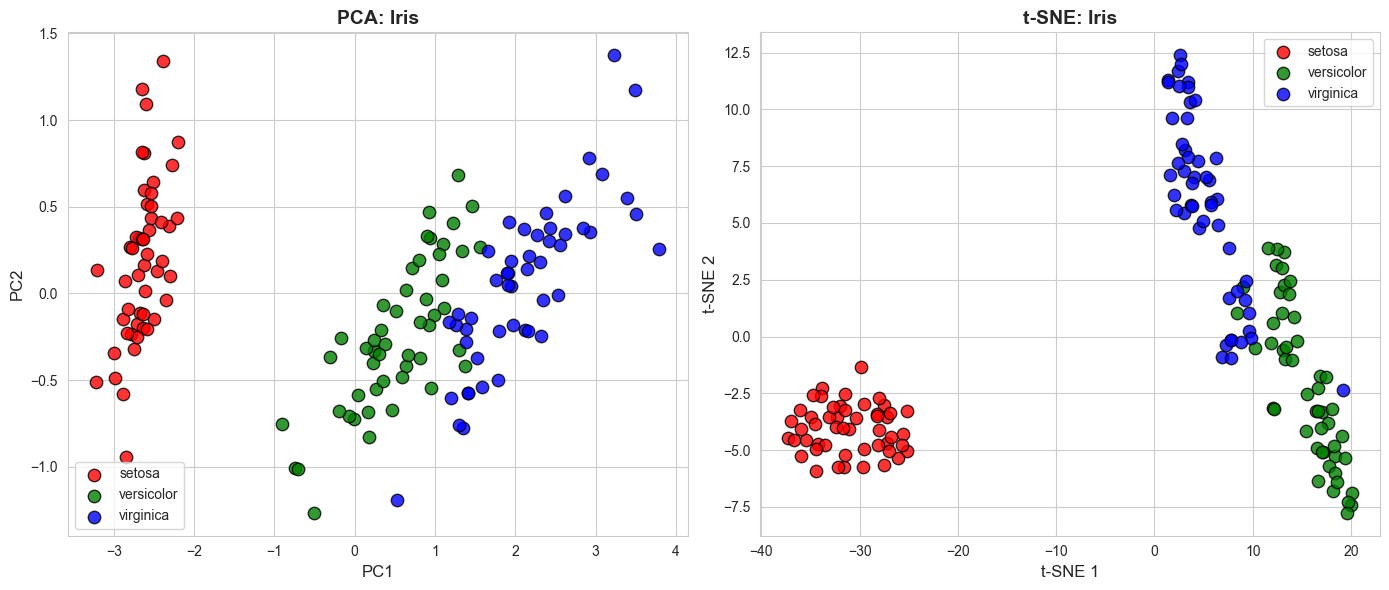

👆 Iris-এর ক্ষেত্রে PCA এবং t-SNE দুটোই ক্লাস আলাদা করতে পেরেছে।
কিন্তু জটিল ডেটার জন্য (যেমন Digits), t-SNE অনেক ভালো কাজ করে।


In [12]:
# Iris ডেটাতে PCA vs t-SNE
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

pca_iris = PCA(n_components=2)
X_iris_pca = pca_iris.fit_transform(X_iris)

tsne_iris = TSNE(n_components=2, random_state=42, perplexity=20)
X_iris_tsne = tsne_iris.fit_transform(X_iris)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['red', 'green', 'blue']
target_names = iris.target_names

for i, tn in enumerate(target_names):
    axes[0].scatter(X_iris_pca[y_iris==i, 0], X_iris_pca[y_iris==i, 1],
                    c=colors[i], label=tn, edgecolors='k', s=80, alpha=0.8)
    axes[1].scatter(X_iris_tsne[y_iris==i, 0], X_iris_tsne[y_iris==i, 1],
                    c=colors[i], label=tn, edgecolors='k', s=80, alpha=0.8)

axes[0].set_title('PCA: Iris', fontsize=14, fontweight='bold')
axes[0].set_xlabel('PC1', fontsize=12)
axes[0].set_ylabel('PC2', fontsize=12)
axes[0].legend()

axes[1].set_title('t-SNE: Iris', fontsize=14, fontweight='bold')
axes[1].set_xlabel('t-SNE 1', fontsize=12)
axes[1].set_ylabel('t-SNE 2', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()
print("👆 Iris-এর ক্ষেত্রে PCA এবং t-SNE দুটোই ক্লাস আলাদা করতে পেরেছে।")
print("কিন্তু জটিল ডেটার জন্য (যেমন Digits), t-SNE অনেক ভালো কাজ করে।")

## 🧪 NMF-এর n_components নির্বাচন

NMF-এর কতগুলো কম্পোনেন্ট লাগবে? PCA-র মতো NMF-এর জন্য explained variance ratio সরাসরি নেই, তবে আমরা পুনর্গঠন ত্রুটি (reconstruction error) দেখে বুঝতে পারি।

Reconstruction error = মূল ডেটা এবং W×H-এর মধ্যে পার্থক্য। কম্পোনেন্ট সংখ্যা বাড়ালে error কমে, কিন্তু মডেল জটিল হয়।

n_components = 30: reconstruction error = 378.88


C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2453 (\N{BENGALI LETTER KA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2478 (\N{BENGALI LETTER MA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2509 (\N{BENGALI SIGN VIRAMA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2474

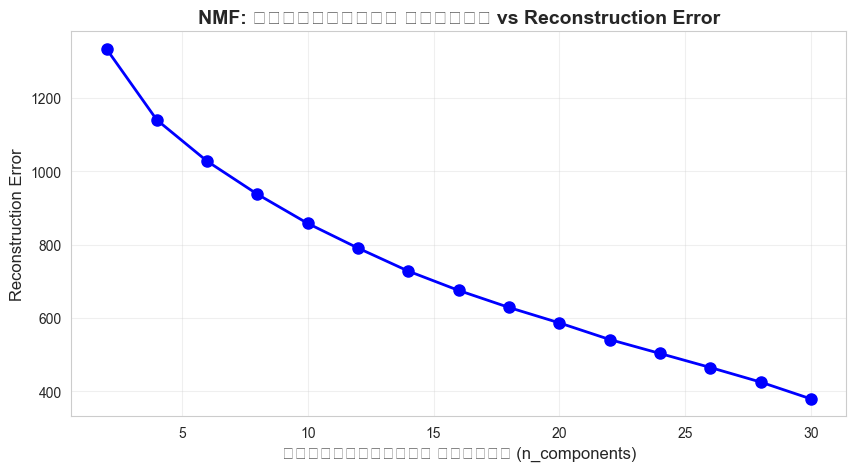

👆 কম্পোনেন্ট সংখ্যা বাড়লে error কমে। কিন্তু 16-র পর error খুব ধীরে কমে — তাই 16টি যথেষ্ট!


In [13]:
# বিভিন্ন n_components-এর সাথে NMF Reconstruction Error
n_components_range = range(2, 31, 2)
reconstruction_errors = []

for n in n_components_range:
    nmf_n = NMF(n_components=n, random_state=42, max_iter=500)
    W_n = nmf_n.fit_transform(X_digits)
    error = nmf_n.reconstruction_err_
    reconstruction_errors.append(error)
print(f"n_components = {n}: reconstruction error = {error:.2f}")

# গ্রাফ
plt.figure(figsize=(10, 5))
plt.plot(n_components_range, reconstruction_errors, 'bo-', markersize=8, linewidth=2)
plt.xlabel('কম্পোনেন্টের সংখ্যা (n_components)', fontsize=12)
plt.ylabel('Reconstruction Error', fontsize=12)
plt.title('NMF: কম্পোনেন্ট সংখ্যা vs Reconstruction Error', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()
print("👆 কম্পোনেন্ট সংখ্যা বাড়লে error কমে। কিন্তু 16-র পর error খুব ধীরে কমে — তাই 16টি যথেষ্ট!")

## 🌟 মজার তথ্য!

🎯 **NMF** ইমেজ প্রসেসিং, টেক্সট মাইনিং (টপিক মডেলিং), এবং অডিও প্রসেসিং-এ ব্যবহৃত হয়।

🎯 **NMF**-এর কম্পোনেন্টগুলো **স্পার্স** (sparse) হয় — মানে অনেকগুলো শূন্য, কিছু কিছু ধনাত্মক। এটা বোঝা সহজ করে।

🎯 **t-SNE** ২০০৮ সালে তৈরি করা হয়েছিল এবং এটি ডেটা সায়েন্সে ভিজুয়ালাইজেশনের জন্য সবচেয়ে জনপ্রিয় টুল।

🎯 **ম্যানিফোল্ড হাইপোথিসিস** বলে যে প্রকৃতির ডেটা (ছবি, অডিও, টেক্সট) আসলে নিচুমাত্রার ম্যানিফোল্ডে থাকে।

🎯 t-SNE-এর নামের 't' আসে **Student's t-distribution** থেকে — এটি নিচুমাত্রায় পয়েন্ট ছড়াতে সাহায্য করে।

## 🧠 তুমি কি বুঝতে পেরেছ?

❓ **প্রশ্ন ১**: NMF এবং PCA-র মধ্যে প্রধান পার্থক্য কী?

❓ **প্রশ্ন ২**: NMF কেন শুধু নন-নেগেটিভ ডেটার জন্য কাজ করে?

❓ **প্রশ্ন ৩**: ম্যানিফোল্ড লার্নিং কী এবং এটি কখন ব্যবহার করা উচিত?

❓ **প্রশ্ন ৪**: t-SNE কেন PCA-র চেয়ে জটিল ডেটার জন্য ভালো?

❓ **প্রশ্ন ৫**: t-SNE-এর perplexity প্যারামিটার কী নিয়ন্ত্রণ করে?

---

**🧪 পরীক্ষা**: উপরের কোডে perplexity = ২, ১০, ৮০ নিয়ে দেখো গ্রাফ কেমন হয়।

---

**📝 মনে রেখো**:
- **NMF** = Non-Negative Matrix Factorization (অংশ-ভিত্তিক পচন)
- **PCA** = লিনিয়ার, NMF = নন-লিনিয়ার
- **t-SNE** = ভিজুয়ালাইজেশনের জন্য সেরা, কিন্তু নতুন ডেটা ট্রান্সফর্ম করতে পারে না
- **ম্যানিফোল্ড লার্নিং** = বাঁকা ডেটার আসল কাঠামো খুঁজে বের করা
- PCA-র আগে **স্কেলিং** জরুরি, কিন্তু t-SNE-র আগে স্কেলিং প্রয়োজন নাও হতে পারে

---

**🎉 অভিনন্দন!** তুমি NMF, ম্যানিফোল্ড লার্নিং, এবং t-SNE-এর মূল ধারণাগুলো শিখে ফেলেছো! এখন তুমি জানো কিভাবে জটিল ডেটাকে সহজে ভিজুয়ালাইজ করতে হয়।